# River Correlation Analysis

This notebook focuses only on river-to-river correlation for imputation support.

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from openpyxl import load_workbook

DATA_DIR = "/Users/ezgi/Desktop/missing data /Donnees Hydro et Meteo Mensuelles_IGEBU"
river_files = sorted(f for f in os.listdir(DATA_DIR) if "Riviere" in f and f.endswith(".xlsx"))

def find_header_row(filepath):
    wb = load_workbook(filepath, data_only=True)
    ws = wb.active
    for i, row in enumerate(ws.iter_rows(max_row=10, values_only=True)):
        vals = [str(v).strip().lower() if v else "" for v in row]
        if "year" in vals or "yy" in vals:
            wb.close()
            return i
    wb.close()
    return 0

def normalize_columns(df):
    col_map = {}
    for c in df.columns:
        cl = str(c).strip().lower()
        if cl in ("station_name", "name"):
            col_map[c] = "Station_Name"
        elif cl == "stationid":
            col_map[c] = "StationID"
        elif cl == "lat":
            col_map[c] = "Lat"
        elif cl == "lon":
            col_map[c] = "Lon"
        elif cl in ("elev", "alt"):
            col_map[c] = "Elev"
        elif cl in ("year", "yy"):
            col_map[c] = "Year"
        elif cl in ("month", "mm"):
            col_map[c] = "Month"
        elif "haut" in cl and "moy" in cl:
            col_map[c] = "haut_moy"
    return df.rename(columns=col_map)

rivers = {}
for fname in river_files:
    path = os.path.join(DATA_DIR, fname)
    header = find_header_row(path)
    df = pd.read_excel(path, header=header)
    df = normalize_columns(df)

    if not set(["Year", "Month", "haut_moy"]).issubset(df.columns):
        continue

    df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
    df["Month"] = pd.to_numeric(df["Month"], errors="coerce")
    df["haut_moy"] = pd.to_numeric(df["haut_moy"], errors="coerce")
    df = df.dropna(subset=["Year", "Month"]).copy()
    df["Year"] = df["Year"].astype(int)
    df["Month"] = df["Month"].astype(int)
    df = df[(df["Month"] >= 1) & (df["Month"] <= 12)]
    df["Date"] = pd.to_datetime(dict(year=df["Year"], month=df["Month"], day=1), errors="coerce")
    df = df.dropna(subset=["Date"]).sort_values("Date").drop_duplicates(subset=["Date"]).reset_index(drop=True)

    full_range = pd.date_range(start=df["Date"].min(), end=df["Date"].max(), freq="MS")
    df = df.set_index("Date").reindex(full_range)
    df.index.name = "Date"

    river_name = fname.replace("Niveaux d'eau de la Riviere ", "").replace(".xlsx", "")
    rivers[river_name] = df

print(f"Loaded {len(rivers)} rivers.")

Loaded 11 rivers.


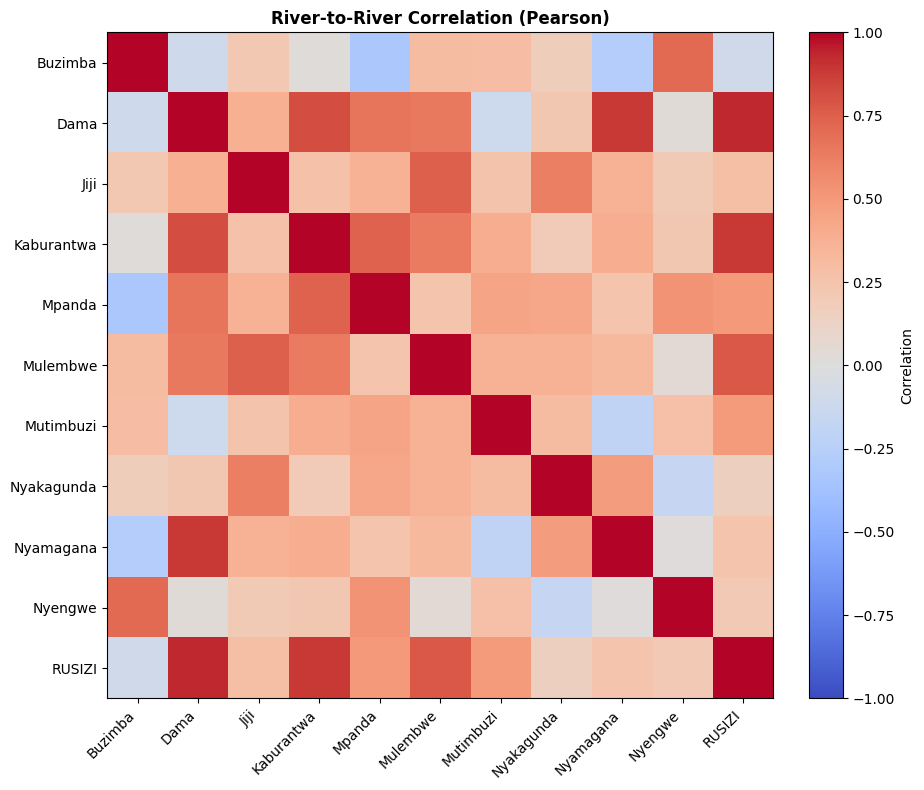

Strong positive correlation (>= 0.70):
  RUSIZI -- Dama: 0.934
  Nyamagana -- Dama: 0.887
  Kaburantwa -- RUSIZI: 0.883
  Kaburantwa -- Dama: 0.817
  RUSIZI -- Mulembwe: 0.777
  Mulembwe -- Jiji: 0.747
  Kaburantwa -- Mpanda: 0.738
  Buzimba -- Nyengwe: 0.709

Moderate positive correlation (0.50 to 0.69):
  Mpanda -- Dama: 0.662
  Mulembwe -- Dama: 0.646
  Mulembwe -- Kaburantwa: 0.633
  Jiji -- Nyakagunda: 0.618
  Nyengwe -- Mpanda: 0.526

Weak or no correlation (|r| < 0.30) [first 20 shown]:
  Nyakagunda -- Mutimbuzi: 0.300
  Buzimba -- Mutimbuzi: 0.296
  RUSIZI -- Jiji: 0.285
  Mutimbuzi -- Nyengwe: 0.280
  Kaburantwa -- Jiji: 0.267
  Mutimbuzi -- Jiji: 0.254
  Nyamagana -- RUSIZI: 0.244
  Nyamagana -- Mpanda: 0.243
  Mulembwe -- Mpanda: 0.242
  Nyakagunda -- Dama: 0.225
  Nyengwe -- Kaburantwa: 0.222
  Jiji -- Buzimba: 0.212
  Nyengwe -- RUSIZI: 0.208
  Nyengwe -- Jiji: 0.203
  Nyakagunda -- Kaburantwa: 0.188
  Nyakagunda -- Buzimba: 0.173
  RUSIZI -- Nyakagunda: 0.154
  Nyengwe --

In [3]:
# Correlation matrix on overlapping non-missing months
river_levels = pd.DataFrame({name: df["haut_moy"] for name, df in rivers.items()})
river_corr = river_levels.corr(method="pearson", min_periods=24)

pairs = river_corr.where(~np.eye(len(river_corr), dtype=bool)).stack().sort_values(ascending=False)
seen = set()
unique_pairs = []
for (a, b), v in pairs.items():
    key = tuple(sorted((a, b)))
    if key in seen:
        continue
    seen.add(key)
    unique_pairs.append((a, b, v))

# ---------- NEW, clearer visualization ----------
# 1) Annotated heatmap (value shown in each cell)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8), gridspec_kw={"width_ratios": [1.25, 1]})

corr_values = river_corr.values
im = ax1.imshow(corr_values, cmap="coolwarm", vmin=-1, vmax=1)

ax1.set_xticks(range(len(river_corr.columns)))
ax1.set_xticklabels(river_corr.columns, rotation=45, ha="right")
ax1.set_yticks(range(len(river_corr.index)))
ax1.set_yticklabels(river_corr.index)
ax1.set_title("Annotated Correlation Heatmap", fontweight="bold")

for i in range(corr_values.shape[0]):
    for j in range(corr_values.shape[1]):
        val = corr_values[i, j]
        text_color = "white" if abs(val) > 0.55 else "black"
        ax1.text(j, i, f"{val:.2f}", ha="center", va="center", color=text_color, fontsize=8)

cbar = plt.colorbar(im, ax=ax1, fraction=0.046, pad=0.04)
cbar.set_label("Pearson r")

# 2) Top correlated pairs bar chart (easier ranking view)
top_n = 10
top_pairs = unique_pairs[:top_n]
labels = [f"{a} - {b}" for a, b, _ in top_pairs][::-1]
values = [v for _, _, v in top_pairs][::-1]

bars = ax2.barh(labels, values, color="steelblue")
ax2.axvline(0.70, color="darkgreen", linestyle="--", linewidth=1.5, label="Strong threshold (0.70)")
ax2.set_xlim(0, 1)
ax2.set_xlabel("Correlation (r)")
ax2.set_title(f"Top {top_n} River Pairs by Correlation", fontweight="bold")
ax2.grid(axis="x", alpha=0.3)
ax2.legend(loc="lower right")

for bar, v in zip(bars, values):
    ax2.text(v + 0.01, bar.get_y() + bar.get_height() / 2, f"{v:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

# ---------- Text outputs ----------
strong = [(a, b, v) for a, b, v in unique_pairs if pd.notna(v) and v >= 0.70]
moderate = [(a, b, v) for a, b, v in unique_pairs if pd.notna(v) and 0.50 <= v < 0.70]
weak = [(a, b, v) for a, b, v in unique_pairs if pd.notna(v) and abs(v) < 0.30]

print("Strong positive correlation (>= 0.70):")
if strong:
    for a, b, v in strong:
        print(f"  {a} -- {b}: {v:.3f}")
else:
    print("  None")

print("\nModerate positive correlation (0.50 to 0.69):")
if moderate:
    for a, b, v in moderate:
        print(f"  {a} -- {b}: {v:.3f}")
else:
    print("  None")

print("\nWeak or no correlation (|r| < 0.30) [first 20 shown]:")
if weak:
    for a, b, v in weak[:20]:
        print(f"  {a} -- {b}: {v:.3f}")
    if len(weak) > 20:
        print(f"  ... and {len(weak) - 20} more pairs")
else:
    print("  None")

print("\nBest donor river for each target river:")
for r in river_corr.columns:
    s = river_corr[r].drop(labels=[r]).dropna()
    if len(s) == 0:
        print(f"  {r}: no valid donor")
    else:
        donor = s.idxmax()
        print(f"  {r}: {donor} ({s.max():.3f})")